# 01 — Exploratory Data Analysis


## 1. Objective


The goal of this exploratory data analysis is to understand the structure, quality, and main patterns in the Financial Inclusion in Africa dataset before building machine learning models.

We want to answer the following questions:

- What does the dataset contain?
- Are there missing values or duplicates?
- How is the target variable (`bank_account`) distributed?
- Is the target imbalanced?
- How are the numerical and categorical features distributed?
- Which features appear to be related to bank account ownership?
- Are there important differences between countries?
- What findings may affect preprocessing, model selection, or evaluation?

## 2. Load Data



In [ ]:
# 📌 Import necessary libraries for data handling, visualization, and modeling
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Libraries imported successfully!


In [5]:
# 📥 Load datasets
train = pd.read_csv('../data/Train.csv')  # Training dataset
test = pd.read_csv('../data/Test.csv')  # Test dataset (no labels)
ss = pd.read_csv('../data/SampleSubmission.csv')  # Sample submission format
variables = pd.read_csv('../data/VariableDefinitions.csv')  # Data dictionary

## 3. Dataset Structure



In [6]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())

print("\nTrain info:")
train.info()

print("\nColumns:")
print(train.columns.tolist())

Train shape: (23524, 13)
Test shape: (10086, 12)


,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed



Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB

Columns:
['country', 'year', 'uniqueid', 'bank

### Observation

- The training dataset contains **23,524 rows and 13 columns**.
- There are **3 numerical columns** and **10 categorical/object columns**.
- The target variable is `bank_account`.
- All columns currently show **23,524 non-null values**, so there are no missing values visible from `train.info()`.

## 4. Data Quality Checks



In [7]:
# Missing values
print("Missing values:")
print(train.isna().sum())

# Duplicate rows
print("\nDuplicate rows:")
print(train.duplicated().sum())

# Duplicate IDs within country
print("\nDuplicate uniqueid + country:")
print(train.duplicated(subset=["uniqueid", "country"]).sum())

# Check target missing values
assert train["bank_account"].isna().sum() == 0

Missing values:
country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64

Duplicate rows:
0

Duplicate uniqueid + country:
0


### Observation

- There are no missing values in any column.
- There are no fully duplicated rows.
- There are no duplicated `uniqueid + country` combinations.
- The target variable `bank_account` has no missing values.

### Interpretation

The dataset appears structurally clean at this stage. No rows need to be removed because of duplicates, and no imputation is required for missing values.

### Modeling Impact

Since there are no missing values or duplicated records, we can focus on feature distributions, class imbalance, and preprocessing of categorical variables in the next steps.

### Observation

- `year` ranges from 2016 to 2018.
- `household_size` has a median of 3 and a maximum of 21.
- `age_of_respondent` has a median of 35 and ranges from 16 to 100 years.
- Some large values, especially in household size and age, should be inspected further before deciding whether they are outliers.

### Interpretation

The numerical variables appear generally reasonable, but their distributions should be visualized to check for skewness and potential outliers.


## 5. Target Analysis



In [12]:
# Target counts
print("Target counts:")
print(train["bank_account"].value_counts())

# Target percentages
print("\nTarget percentages:")
print(train["bank_account"].value_counts(normalize=True) * 100)

Target counts:
bank_account
No     20212
Yes     3312
Name: count, dtype: int64

Target percentages:
bank_account
No     85.920762
Yes    14.079238
Name: proportion, dtype: float64


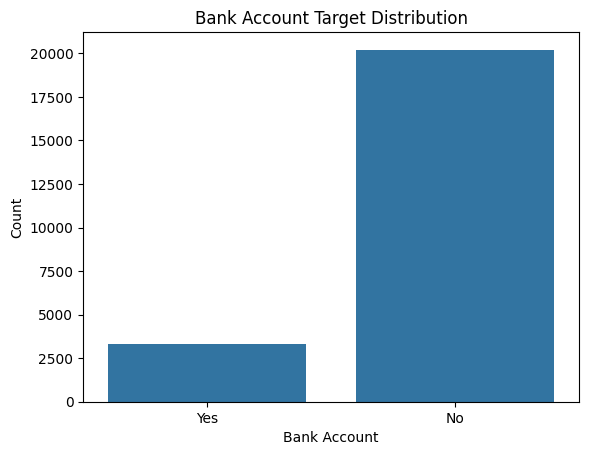

In [13]:
sns.countplot(data=train, x="bank_account")
plt.title("Bank Account Target Distribution")
plt.xlabel("Bank Account")
plt.ylabel("Count")
plt.show()

### Observation

- `bank_account = No`: 20,212 respondents (**85.92%**)
- `bank_account = Yes`: 3,312 respondents (**14.08%**)
- The target variable is strongly imbalanced toward the `No` class.

### Interpretation

Most respondents in the dataset do not have a bank account. Because the `Yes` class represents only about 14% of the data, a model could achieve high accuracy by predicting the majority class too often.

### Modeling Impact

Accuracy alone may be misleading for this problem. We should also evaluate models using metrics such as:

- Precision
- Recall
- F1-score
- Macro F1-score
- Confusion Matrix

We should pay particular attention to performance on the minority class (`bank_account = Yes`).

## 6. Numerical Features



In [ ]:
train[["year", "household_size", "age_of_respondent"]].describe()

,year,household_size,age_of_respondent
count,23524.000000,23524.000000,23524.000000
mean,2016.975939,3.797483,38.805220
std,0.847371,2.227613,16.520569
min,2016.000000,1.000000,16.000000
25%,2016.000000,2.000000,26.000000
50%,2017.000000,3.000000,35.000000
75%,2018.000000,5.000000,49.000000
max,2018.000000,21.000000,100.000000


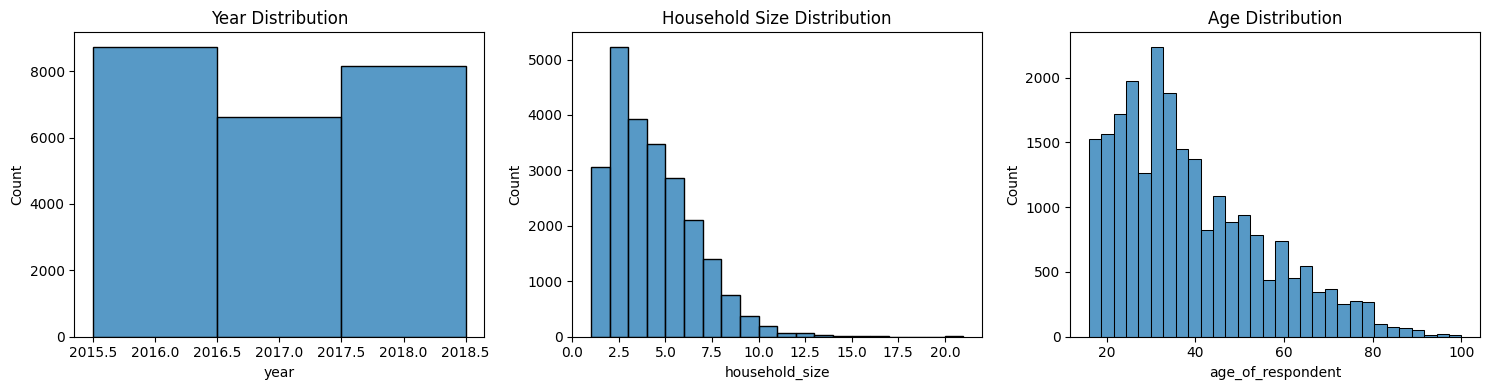

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(train["year"], ax=axes[0], discrete=True)
axes[0].set_title("Year Distribution")

sns.histplot(train["household_size"], ax=axes[1], bins=20)
axes[1].set_title("Household Size Distribution")

sns.histplot(train["age_of_respondent"], ax=axes[2], bins=30)
axes[2].set_title("Age Distribution")

plt.tight_layout()
plt.show()

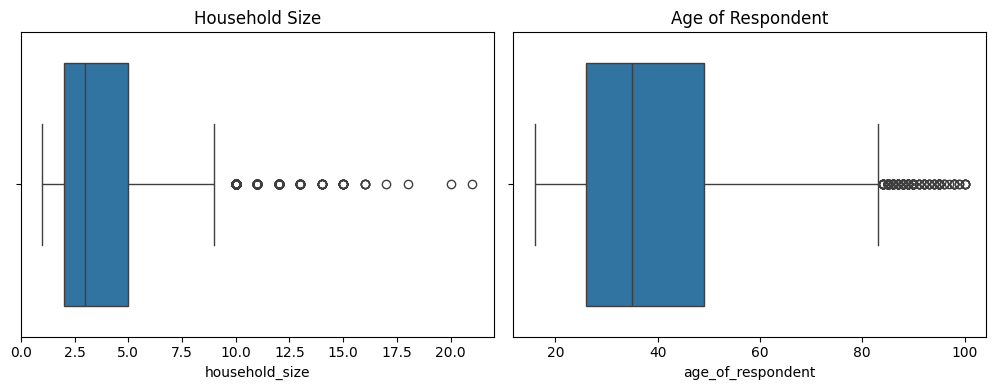

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(x=train["household_size"], ax=axes[0])
axes[0].set_title("Household Size")

sns.boxplot(x=train["age_of_respondent"], ax=axes[1])
axes[1].set_title("Age of Respondent")

plt.tight_layout()
plt.show()

## 7. Categorical Features



In [ ]:
categorical_cols = train.select_dtypes(include="object").columns.tolist()

print("Categorical columns:")
print(categorical_cols)

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(train[col].value_counts())

Categorical columns:
['country', 'uniqueid', 'bank_account', 'location_type', 'cellphone_access', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']

--- country ---
country
Rwanda      8735
Tanzania    6620
Kenya       6068
Uganda      2101
Name: count, dtype: int64

--- uniqueid ---
uniqueid
uniqueid_1       4
uniqueid_1413    4
uniqueid_1411    4
uniqueid_1410    4
uniqueid_1409    4
                ..
uniqueid_7318    1
uniqueid_7317    1
uniqueid_7316    1
uniqueid_7315    1
uniqueid_8759    1
Name: count, Length: 8735, dtype: int64

--- bank_account ---
bank_account
No     20212
Yes     3312
Name: count, dtype: int64

--- location_type ---
location_type
Rural    14343
Urban     9181
Name: count, dtype: int64

--- cellphone_access ---
cellphone_access
Yes    17454
No      6070
Name: count, dtype: int64

--- gender_of_respondent ---
gender_of_respondent
Female    13877
Male       9647
Name: count, dtype: int64

--- relationship_with_h

### Observation

- The categorical variables contain a manageable number of categories, with no obvious spelling inconsistencies or unexpected category labels.
- Rwanda has the largest number of observations, while Uganda has the fewest.
- Rural respondents are more common than urban respondents.
- Most respondents report having access to a cellphone.
- Female respondents are more common than male respondents.
- Primary education is the most common education level.
- Self-employment, informal employment, and farming/fishing are the most common job categories.
- `uniqueid` values can repeat across countries, but the combination of `uniqueid + country` is unique.

### Interpretation

The categorical distributions are not uniform. Some groups are much more common than others, so raw counts alone may be misleading when comparing relationships with the target.

### Modeling Impact

Categorical variables will require encoding before modeling. For EDA, we should compare target rates within each category rather than only comparing category counts.

## 8. Feature vs Target Analysis



In [18]:
yes_group = train[train["bank_account"] == "Yes"]

categorical_features = [
    "location_type",
    "cellphone_access",
    "gender_of_respondent",
    "relationship_with_head",
    "marital_status",
    "education_level",
    "job_type"
]

for col in categorical_features:
    print(f"\n--- {col} ---")
    
    percentages = (
        yes_group[col]
        .value_counts(normalize=True)
        * 100
    )
    
    print(percentages.round(2))


--- location_type ---
location_type
Rural    50.45
Urban    49.55
Name: proportion, dtype: float64

--- cellphone_access ---
cellphone_access
Yes    96.86
No      3.14
Name: proportion, dtype: float64

--- gender_of_respondent ---
gender_of_respondent
Male      55.25
Female    44.75
Name: proportion, dtype: float64

--- relationship_with_head ---
relationship_with_head
Head of Household      68.63
Spouse                 20.98
Child                   5.83
Other relative          1.99
Parent                  1.96
Other non-relatives     0.60
Name: proportion, dtype: float64

--- marital_status ---
marital_status
Married/Living together    56.34
Single/Never Married       29.17
Widowed                     7.37
Divorced/Seperated          7.07
Dont know                   0.06
Name: proportion, dtype: float64

--- education_level ---
education_level
Primary education                  33.00
Secondary education                29.68
Tertiary education                 17.84
Vocational/Speciali

In [19]:
cellphone_target = pd.crosstab(
    train["cellphone_access"],
    train["bank_account"],
    normalize="index"
) * 100

print(cellphone_target.round(2))

bank_account         No    Yes
cellphone_access              
No                98.29   1.71
Yes               81.62  18.38


In [21]:
for col in categorical_features:
    print(f"\n--- {col} ---")
    
    result = pd.crosstab(
        train[col],
        train["bank_account"],
        normalize="index"
    ) * 100
    
    print(result.round(2))


--- location_type ---
bank_account      No    Yes
location_type              
Rural          88.35  11.65
Urban          82.13  17.87

--- cellphone_access ---
bank_account         No    Yes
cellphone_access              
No                98.29   1.71
Yes               81.62  18.38

--- gender_of_respondent ---
bank_account             No    Yes
gender_of_respondent              
Female                89.32  10.68
Male                  81.03  18.97

--- relationship_with_head ---
bank_account               No    Yes
relationship_with_head              
Child                   91.34   8.66
Head of Household       82.29  17.71
Other non-relatives     89.47  10.53
Other relative          90.12   9.88
Parent                  94.01   5.99
Spouse                  89.34  10.66

--- marital_status ---
bank_account                No    Yes
marital_status                       
Divorced/Seperated       88.73  11.27
Dont know                75.00  25.00
Married/Living together  82.64  17.36
Sin

### Key Findings from Feature vs Target Analysis

- `cellphone_access` shows a strong association with bank account ownership. Only 1.71% of respondents without cellphone access have a bank account, compared with 18.38% of those with cellphone access.
- `gender_of_respondent` also shows a noticeable difference: 18.97% of male respondents have a bank account compared with 10.68% of female respondents.
- `location_type` shows a smaller difference, with urban respondents having a higher ownership rate (17.87%) than rural respondents (11.65%).
- `relationship_with_head` varies across groups, with heads of household having a relatively higher ownership rate (17.71%).
- `education_level` shows a strong pattern: bank account ownership increases substantially for higher education levels. Tertiary education and vocational/specialised training have much higher ownership rates than primary or no formal education.
- `job_type` shows some of the largest differences. Formally employed government and private workers have high ownership rates, while respondents with no income or informal employment have much lower rates.
- `marital_status` shows some variation, but the very small `Dont know` group should be interpreted cautiously.

### Interpretation

Several categorical features are clearly associated with bank account ownership, especially cellphone access, education level, job type, gender, and location type. However, these relationships describe association rather than causation.

### Modeling Impact

These categorical variables appear potentially informative for prediction and should be retained and encoded during preprocessing. Features with large differences in ownership rates, particularly education level, job type, and cellphone access, may be especially useful to the model.

## 9. Country-Level Analysis



In [22]:
country_analysis = (
    train.groupby("country")["bank_account"]
    .value_counts(normalize=True)
    .unstack()
    * 100
)

print(country_analysis.round(2))

bank_account     No    Yes
country                   
Kenya         74.93  25.07
Rwanda        88.52  11.48
Tanzania      90.83   9.17
Uganda        91.39   8.61


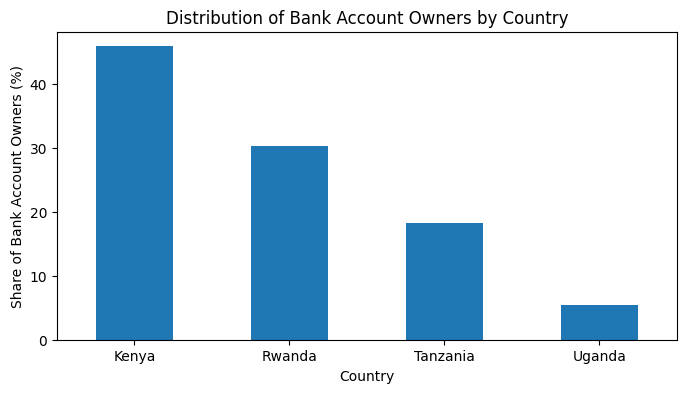

In [23]:
country_yes_rate = (
    train[train["bank_account"] == "Yes"]["country"]
    .value_counts(normalize=True)
    * 100
)

country_yes_rate.plot(kind="bar", figsize=(8, 4))

plt.title("Distribution of Bank Account Owners by Country")
plt.xlabel("Country")
plt.ylabel("Share of Bank Account Owners (%)")
plt.xticks(rotation=0)
plt.show()

### Country-Level Findings

- Bank account ownership varies substantially across countries.
- Kenya has the highest ownership rate at 25.07%.
- Rwanda follows with 11.48%.
- Tanzania and Uganda have lower ownership rates at 9.17% and 8.61%, respectively.
- Kenya also represents the largest share of all respondents with a bank account in the dataset.

### Interpretation

Country appears to be strongly associated with bank account ownership. The large differences in ownership rates suggest that country-level economic, social, or financial-access conditions may influence the target.

### Modeling Impact

`country` should be retained as an important categorical feature. Because ownership patterns differ substantially between countries, the model may benefit from learning these country-level differences.

## 10. Key EDA Findings



## 10. Key EDA Findings

- The dataset is structurally clean, with no missing values or duplicate rows.
- The target is strongly imbalanced: only 14.08% of respondents have a bank account.
- Cellphone access shows a strong association with bank account ownership.
- Higher education levels are associated with substantially higher ownership rates.
- Employment type shows large differences in ownership, especially between formal employment and low/no-income groups.
- Urban and male respondents show higher ownership rates than rural and female respondents.
- Bank account ownership also varies substantially by country, with Kenya showing the highest ownership rate.
- Numerical features such as age and household size contain skewness and statistical outliers, but the values appear plausible and were retained.

## 11. Modeling Implications


- Because the target is strongly imbalanced, accuracy should not be used as the only evaluation metric.
- Macro F1 should be used as the main model comparison metric, while minority-class recall, F1-score, and the confusion matrix should also be monitored.
- Categorical features such as `country`, `education_level`, `job_type`, `cellphone_access`, and other demographic variables need to be encoded before modeling.
- `uniqueid` should not be used as a predictive feature because it acts as an identifier rather than meaningful information about the respondent.
- Numerical features such as `age_of_respondent` and `household_size` should initially be retained, including their extreme but plausible values.
- Scaling may be useful for models such as Logistic Regression, while tree-based models are less sensitive to feature scaling.
- Features that showed strong associations with the target, especially cellphone access, education level, job type, and country, should be retained and evaluated during modeling.
- A reproducible preprocessing pipeline should be created so that the same transformations are applied consistently to training, validation, and test data.